In [53]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import Polygon
from shapely.ops import unary_union
import numpy as np
from datetime import datetime
import os


In [23]:
# Load IBTrACS shapefiles
points_gdf = gpd.read_file("IBTrACS.WP.list.v04r01.points.shp")
lines_gdf = gpd.read_file("IBTrACS.WP.list.v04r01.lines.shp")

# Load Philippines administrative boundary
boundary_gdf = gpd.read_file("PHL_adm0.shp")
buffer_gdf = gpd.read_file("PHL_1degree_buffer.shp")

In [24]:
# Filter for Typhoon Rai (2021) using SID 2021346N05145
rai_points = points_gdf[points_gdf['SID'] == '2021346N05145']
rai_lines = lines_gdf[lines_gdf['SID'] == '2021346N05145']

In [25]:
# Ensure CRS consistency
phl_buffer = buffer_gdf.to_crs("EPSG:4326")
phl_adm0 = boundary_gdf.to_crs("EPSG:4326")
rai_points = rai_points.to_crs("EPSG:4326")
rai_lines = rai_lines.to_crs("EPSG:4326")


In [26]:
r64_columns = ['USA_R64_NE', 'USA_R64_SE', 'USA_R64_SW', 'USA_R64_NW']
has_r64_data = rai_points[r64_columns].notna().any().all()
print("USA_R64 wind radii data available for Typhoon Rai 2021:", has_r64_data)

USA_R64 wind radii data available for Typhoon Rai 2021: True


In [35]:
# Convert ISO_TIME to datetime
rai_points['ISO_TIME'] = pd.to_datetime(rai_points['ISO_TIME'])
print(rai_points)
rai_lines['ISO_TIME'] = pd.to_datetime(rai_lines['ISO_TIME'])
print(rai_lines)

                  SID  SEASON  NUMBER BASIN SUBBASIN NAME            ISO_TIME  \
239876  2021346N05145    2021     104    WP       MM  RAI 2021-12-11 12:00:00   
239877  2021346N05145    2021     104    WP       MM  RAI 2021-12-11 15:00:00   
239878  2021346N05145    2021     104    WP       MM  RAI 2021-12-11 18:00:00   
239879  2021346N05145    2021     104    WP       MM  RAI 2021-12-11 21:00:00   
239880  2021346N05145    2021     104    WP       MM  RAI 2021-12-12 00:00:00   
...               ...     ...     ...   ...      ...  ...                 ...   
239952  2021346N05145    2021     104    WP       MM  RAI 2021-12-21 00:00:00   
239953  2021346N05145    2021     104    WP       MM  RAI 2021-12-21 03:00:00   
239954  2021346N05145    2021     104    WP       MM  RAI 2021-12-21 06:00:00   
239955  2021346N05145    2021     104    WP       MM  RAI 2021-12-21 09:00:00   
239956  2021346N05145    2021     104    WP       MM  RAI 2021-12-21 12:00:00   

       NATURE   LAT    LON 

In [36]:
# Identify entry and exit times within the buffer
rai_within_buffer = gpd.sjoin(rai_points, buffer_gdf, how='inner', predicate='within')
rai_within_buffer

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,geometry,index_right,iso3,status,color_code,name,continent,region,iso_3166_1,french_sho
239913,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 03:00:00,TS,9.8,126.8,...,POINT (126.8 9.8),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239914,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 06:00:00,TS,10.0,126.0,...,POINT (126 10),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239915,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 09:00:00,TS,10.0,125.1,...,POINT (125.1 10),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239916,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 12:00:00,TS,10.1,124.2,...,POINT (124.2 10.1),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239917,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 15:00:00,TS,10.1,123.3,...,POINT (123.3 10.1),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239918,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 18:00:00,TS,10.1,122.5,...,POINT (122.5 10.1),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239919,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 21:00:00,TS,10.1,121.7,...,POINT (121.7 10.1),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239920,2021346N05145,2021,104,WP,MM,RAI,2021-12-17 00:00:00,TS,10.1,121.0,...,POINT (121 10.1),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239921,2021346N05145,2021,104,WP,MM,RAI,2021-12-17 03:00:00,TS,10.1,120.5,...,POINT (120.5 10.1),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines
239922,2021346N05145,2021,104,WP,MM,RAI,2021-12-17 06:00:00,TS,10.3,119.9,...,POINT (119.9 10.3),0,PHL,Member State,PHL,Philippines,Asia,South-Eastern Asia,PH,Philippines


In [37]:
entry_time = rai_within_buffer['ISO_TIME'].min()
exit_time = rai_within_buffer['ISO_TIME'].max()
print(f"RAI entered buffer at: {entry_time}")
print(f"RAI exited buffer at: {exit_time}")


RAI entered buffer at: 2021-12-16 03:00:00
RAI exited buffer at: 2021-12-17 15:00:00


In [38]:
# Filter points within the time range
rai_impact_points = rai_points[(rai_points['ISO_TIME'] >= entry_time) &
                              (rai_points['ISO_TIME'] <= exit_time)]
rai_impact_points

rai_impact_lines = rai_lines[(rai_lines['ISO_TIME'] >= entry_time) &
                              (rai_lines['ISO_TIME'] <= exit_time)]
rai_impact_lines

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,USA_SEA_SW,USA_SEA_NW,STORM_SPD,STORM_DR,year,month,day,hour,min,geometry
235807,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 03:00:00,TS,9.8,126.8,...,NaN,NaN,16,280,2021,12,16,3,0,"LINESTRING (126.80005 9.8, 126 10)"
235808,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 06:00:00,TS,10.0,126.0,...,NaN,NaN,17,275,2021,12,16,6,0,"LINESTRING (126 10, 125.09998 10)"
235809,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 09:00:00,TS,10.0,125.1,...,NaN,NaN,18,275,2021,12,16,9,0,"LINESTRING (125.09998 10, 124.19995 10.1)"
235810,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 12:00:00,TS,10.1,124.2,...,NaN,NaN,18,275,2021,12,16,12,0,"LINESTRING (124.19995 10.1, 123.30005 10.1)"
235811,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 15:00:00,TS,10.1,123.3,...,NaN,NaN,17,270,2021,12,16,15,0,"LINESTRING (123.30005 10.1, 122.5 10.1)"
235812,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 18:00:00,TS,10.1,122.5,...,NaN,NaN,15,270,2021,12,16,18,0,"LINESTRING (122.5 10.1, 121.69995 10.1)"
235813,2021346N05145,2021,104,WP,MM,RAI,2021-12-16 21:00:00,TS,10.1,121.7,...,NaN,NaN,14,265,2021,12,16,21,0,"LINESTRING (121.69995 10.1, 121 10.1)"
235814,2021346N05145,2021,104,WP,MM,RAI,2021-12-17 00:00:00,TS,10.1,121.0,...,NaN,NaN,13,275,2021,12,17,0,0,"LINESTRING (121 10.1, 120.5 10.1)"
235815,2021346N05145,2021,104,WP,MM,RAI,2021-12-17 03:00:00,TS,10.1,120.5,...,NaN,NaN,11,280,2021,12,17,3,0,"LINESTRING (120.5 10.1, 119.90002 10.3)"
235816,2021346N05145,2021,104,WP,MM,RAI,2021-12-17 06:00:00,TS,10.3,119.9,...,NaN,NaN,12,280,2021,12,17,6,0,"LINESTRING (119.90002 10.3, 119.30005 10.3)"


In [39]:
# Extract wind radii data (USA_R64_NE, USA_R64_SE, USA_R64_SW, USA_R64_NW)
wind_columns = ['ISO_TIME', 'LAT', 'LON', 'USA_WIND', 'USA_R64_NE', 'USA_R64_SE', 'USA_R64_SW', 'USA_R64_NW']
wind_data = rai_impact_points[wind_columns].copy()
wind_data = wind_data.rename(columns={
    'USA_R64_NE': 'R64_NE_nm', 'USA_R64_SE': 'R64_SE_nm',
    'USA_R64_SW': 'R64_SW_nm', 'USA_R64_NW': 'R64_NW_nm'
})
wind_data

,ISO_TIME,LAT,LON,USA_WIND,R64_NE_nm,R64_SE_nm,R64_SW_nm,R64_NW_nm
239913,2021-12-16 03:00:00,9.8,126.8,143.0,60.0,73.0,28.0,48.0
239914,2021-12-16 06:00:00,10.0,126.0,135.0,70.0,85.0,30.0,50.0
239915,2021-12-16 09:00:00,10.0,125.1,128.0,65.0,63.0,35.0,48.0
239916,2021-12-16 12:00:00,10.1,124.2,120.0,60.0,40.0,40.0,45.0
239917,2021-12-16 15:00:00,10.1,123.3,115.0,55.0,35.0,43.0,45.0
239918,2021-12-16 18:00:00,10.1,122.5,110.0,50.0,30.0,45.0,45.0
239919,2021-12-16 21:00:00,10.1,121.7,103.0,40.0,25.0,48.0,45.0
239920,2021-12-17 00:00:00,10.1,121.0,95.0,30.0,20.0,50.0,45.0
239921,2021-12-17 03:00:00,10.1,120.5,90.0,35.0,35.0,53.0,45.0
239922,2021-12-17 06:00:00,10.3,119.9,85.0,40.0,50.0,55.0,45.0


/tmp/ipython-input-77-3989508708.py:40: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


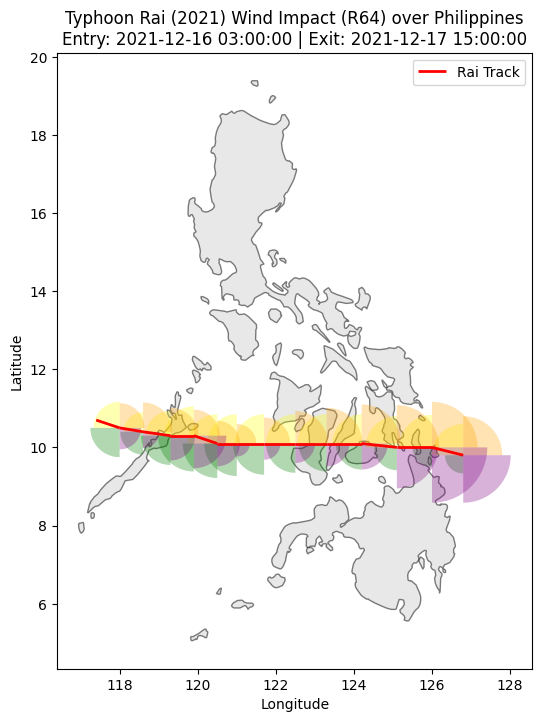

In [77]:
# Create map visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Philippines boundary and buffer
phl_adm0.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5, label='Philippines Boundary')

# Plot Rai's track
rai_impact_lines.plot(ax=ax, color='red', linewidth=2, label='Rai Track')

for idx, row in rai_impact_points.iterrows():
    lon, lat = row['LON'], row['LAT']
    center = Point(lon, lat)
    quadrants = [
        ('USA_R64_NE', 0, 90, 'orange'),   # NE: 0° to 90° in clockwise from N to E
        ('USA_R64_SE', 270, 360, 'purple'), # SE: 270° to 360° in anti clockwise from S to E
        ('USA_R64_SW', 180, 270, 'green'), # SW: 180° to 270° in clockwise from S to W
        ('USA_R64_NW', 90, 180, 'yellow') # NW: 90° to 180° in anti clockwise from N to W
    ]
    for radius_col, start_angle, end_angle, color in quadrants:
        radius_nm = row[radius_col]
        if pd.notnull(radius_nm):
            # Convert nautical miles to degrees (1 nm ≈ 1/60 degree)
            radius_deg = radius_nm / 60
            # Create points for a 90-degree arc (quadrant sector)
            angles = np.linspace(start_angle, end_angle, 20)  # 20 points for smooth arc
            points = [(lon, lat)]  # Start with center
            for angle in angles:
                rad = np.deg2rad(angle)
                x = lon + radius_deg * np.cos(rad)
                y = lat + radius_deg * np.sin(rad)
                points.append((x, y))
            points.append((lon, lat))  # Close the sector back to center
            sector = Polygon(points)
            gpd.GeoSeries([sector]).plot(ax=ax, color=color, alpha=0.3)

# Add title and labels
plt.title(f"Typhoon Rai (2021) Wind Impact (R64) over Philippines\nEntry: {entry_time} | Exit: {exit_time}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

# Save and show plot
plt.savefig("rai_wind_impact_map.png", dpi=300, bbox_inches='tight')
